# Classification with a Perceptron — The Log Loss

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture introducing the **log loss** for a
classification perceptron (Week 3 — Optimization in Neural Networks and Newton's Method).

This notebook explains:

- a worked forward pass through the classification perceptron (sigmoid output)
- why squared error is replaced by the **log loss** for classification
- the formula $L(y, \hat{y}) = -y\log\hat{y} - (1-y)\log(1-\hat{y})$ and its behaviour
- the **probabilistic** interpretation (the coin / maximum-likelihood connection)
- the optimization goal and the gradient-descent update rules

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*The Sigmoid Function*.

## 1. A forward pass through the perceptron

Take the sentence **"aack beep beep beep"**: the word *aack* appears once ($x_1 = 1$) and
*beep* three times ($x_2 = 3$). Suppose mid-training the weights are
$w_1 = 4.5,\; w_2 = 1.5,\; b = 2$.

The perceptron computes the summation, then the sigmoid:

$$
z = w_1 x_1 + w_2 x_2 + b, \qquad \hat{y} = \sigma(z) = \frac{1}{1+e^{-z}} .
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

x1, x2 = 1, 3
w1, w2, b = 4.5, 1.5, 2.0

z = w1*x1 + w2*x2 + b
y_hat = sigmoid(z)
print(f"z = {w1}*{x1} + {w2}*{x2} + {b} = {z}")
print(f"y_hat = σ(z) = {y_hat:.6f}")
print("The model is very confident the sentence is HAPPY (≈1).")

z = 4.5*1 + 1.5*3 + 2.0 = 11.0
y_hat = σ(z) = 0.999983
The model is very confident the sentence is HAPPY (≈1).


## 2. We need a loss — but which one?

Suppose the true label is $y = 0$ (the sentence is actually **sad**). The model predicted
$\hat{y} \approx 1$, so it is badly wrong. We measure "how wrong" with a **loss function**,
then use it to update $w_1, w_2, b$.

> *"You may think $\hat{y} - y$, or $(\hat{y}-y)^2$, or $\tfrac12(\hat{y}-y)^2$... those
> work. But for classification, the one that works best is called the **log loss**."*

## 3. The log loss

For binary classification the log loss (a.k.a. binary cross-entropy) is

$$
L(y, \hat{y}) = -\,y\log(\hat{y}) - (1-y)\log(1-\hat{y}).
$$

It splits into two cases:

- if $y = 1$: $\;L = -\log(\hat{y})$ — small when $\hat{y}$ is near $1$, large near $0$,
- if $y = 0$: $\;L = -\log(1-\hat{y})$ — small when $\hat{y}$ is near $0$, large near $1$.

> *"$L(y,\hat{y})$ is large when $y$ and $\hat{y}$ are far apart, and small when they are
> close."*

In [2]:
def log_loss(y, y_hat, eps=1e-12):
    y_hat = np.clip(y_hat, eps, 1 - eps)        # avoid log(0)
    return -y*np.log(y_hat) - (1-y)*np.log(1-y_hat)

# the example: predicted ~1 but the true label is sad (y=0)
L = log_loss(0, y_hat)
print(f"log loss for the example (y=0, y_hat={y_hat:.5f}): L = {L:.4f}")
print("A large loss -> a large correction to the weights.")

log loss for the example (y=0, y_hat=0.99998): L = 11.0000
A large loss -> a large correction to the weights.


### How the log loss penalizes wrong confidence

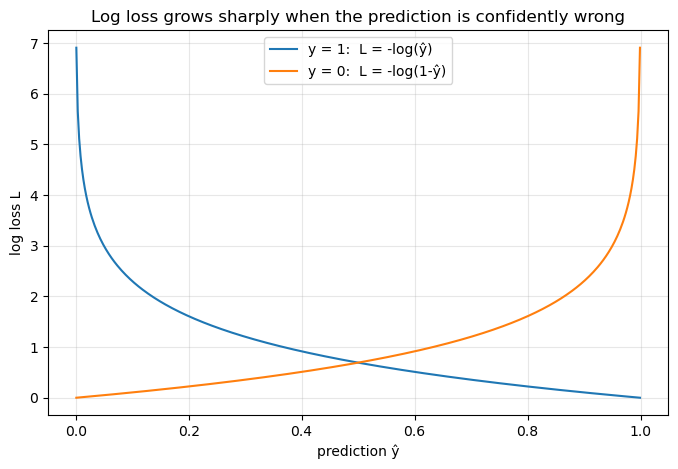

In [3]:
p = np.linspace(0.001, 0.999, 400)

plt.figure(figsize=(8, 5))
plt.plot(p, log_loss(1, p), label="y = 1:  L = -log(ŷ)")
plt.plot(p, log_loss(0, p), label="y = 0:  L = -log(1-ŷ)")
plt.title("Log loss grows sharply when the prediction is confidently wrong")
plt.xlabel("prediction ŷ"); plt.ylabel("log loss L")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 4. The probabilistic interpretation

> *"This function has a probabilistic nature... the same reason it came out of the coin
> example."*

Recall the coin example: a coin flipped 10 times giving 7 heads and 3 tails, where the
"perfect" coin was found by minimizing a loss with a logarithm. The log loss is exactly the
**negative log-likelihood**, so minimizing it = finding the most likely model.

Classification is naturally probabilistic: the sigmoid output $\hat{y}$ is a
**probability**. $\hat{y} = 0.8$ means the model gives the sentence an **80 % chance** of
being happy.

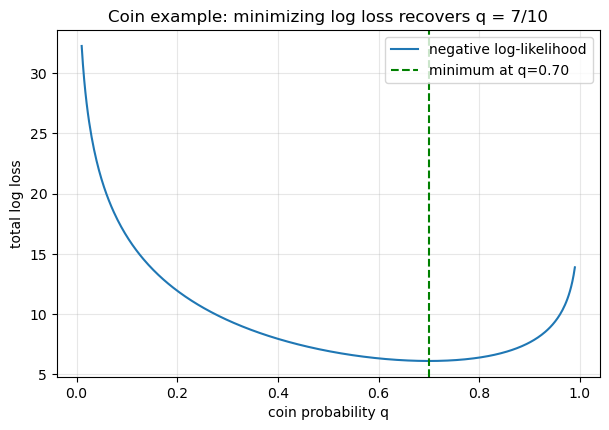

best coin probability = 0.700  (expected 0.7)


In [4]:
# log loss = negative log-likelihood of a Bernoulli(ŷ) model
# 7 heads, 3 tails out of 10: the minimizing probability is 0.7
q = np.linspace(0.01, 0.99, 400)
neg_log_lik = -(7*np.log(q) + 3*np.log(1-q))     # sum of log losses over the flips

best = q[np.argmin(neg_log_lik)]
plt.figure(figsize=(7, 4.5))
plt.plot(q, neg_log_lik, label="negative log-likelihood")
plt.axvline(best, color="green", ls="--", label=f"minimum at q={best:.2f}")
plt.title("Coin example: minimizing log loss recovers q = 7/10")
plt.xlabel("coin probability q"); plt.ylabel("total log loss")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()
print(f"best coin probability = {best:.3f}  (expected 0.7)")

## 5. The optimization goal and gradient descent

The goal: find $w_1, w_2, b$ that give predictions $\hat{y}$ with the **least log loss**.
As before, we use **gradient descent**:

$$
w_1 \leftarrow w_1 - \alpha\,\frac{\partial L}{\partial w_1}, \qquad
w_2 \leftarrow w_2 - \alpha\,\frac{\partial L}{\partial w_2}, \qquad
b \leftarrow b - \alpha\,\frac{\partial L}{\partial b}.
$$

Start with arbitrary weights, compute the partial derivatives, and update — repeatedly.

> *"In the next video... the sigmoid and the log loss conspire really nicely to get some
> very nice derivatives."*

(That clean result — the same $-(y - \hat{y})$ factor as in regression — is derived in the
next notebook.)

## 6. Exercises

### Basic
1. Write the log-loss formula for binary classification.
2. For the example ($x_1=1, x_2=3$, $w_1=4.5, w_2=1.5, b=2$), compute $z$ and $\hat{y}$.

### Intermediate
3. Compute the log loss for the example if the true label is $y=0$, and again if $y=1$.
   Which is larger, and why?
4. Why is the log loss preferred over squared error for a classification (sigmoid) output?

### Advanced
5. Show that for 7 heads and 3 tails, the coin probability $q$ minimizing the total log
   loss is $q = 0.7$.
6. Explain the probabilistic meaning of an output $\hat{y} = 0.8$.

## 7. Solutions / Checks

In [5]:
# 2.
z = 4.5*1 + 1.5*3 + 2.0
yh = sigmoid(z)
print(f"2. z = {z}, y_hat = {yh:.6f}")

# 3.
print(f"3. y=0 -> L = {log_loss(0, yh):.4f};  y=1 -> L = {log_loss(1, yh):.6f}")
print("   y=0 is far larger: the model was confidently happy but the truth was sad.")

# 5. coin
q = np.linspace(0.01, 0.99, 999)
qbest = q[np.argmin(-(7*np.log(q) + 3*np.log(1-q)))]
print(f"5. minimizing coin probability = {qbest:.3f} (= 7/10)")

print("4. Squared error on a sigmoid output is non-convex and gives weak gradients when "
      "wrong; log loss is convex in the score and penalizes confident mistakes strongly.")
print("6. ŷ = 0.8 means the model assigns an 80% probability to the positive class (happy).")

2. z = 11.0, y_hat = 0.999983
3. y=0 -> L = 11.0000;  y=1 -> L = 0.000017
   y=0 is far larger: the model was confidently happy but the truth was sad.
5. minimizing coin probability = 0.700 (= 7/10)
4. Squared error on a sigmoid output is non-convex and gives weak gradients when wrong; log loss is convex in the score and penalizes confident mistakes strongly.
6. ŷ = 0.8 means the model assigns an 80% probability to the positive class (happy).


## 8. Conclusion

- The classification perceptron outputs a probability $\hat{y} = \sigma(z)$.
- For classification we use the **log loss**
  $L(y,\hat{y}) = -y\log\hat{y} - (1-y)\log(1-\hat{y})$, which is small when prediction and
  label agree and grows sharply for confident mistakes.
- It is the **negative log-likelihood** — the same quantity minimized in the coin example —
  giving it a clean probabilistic meaning.
- Training minimizes the log loss over $w_1, w_2, b$ with **gradient descent**; the next
  notebook derives the (surprisingly simple) gradients.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/opt_nns_6.mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 3) lecture introducing the **log loss** (the two alien words are written
here as "aack" and "beep"). Key spoken points, lightly cleaned:

> Back to the perceptron: for the sentence "aack beep beep beep", $x_1=1$ and $x_2=3$, with
> mid-training weights $w_1=4.5, w_2=1.5, b=2$. The perceptron multiplies inputs by weights,
> sums, and applies the sigmoid to get $\hat{y}$, which we compare to the true label with a
> loss to update the weights. If $y=0$ (sad), we measure how far $\hat{y}$ is from $y$.
> Squared-error losses work, but for classification the best is the log loss
> $L(y,\hat{y})$. It is small when $y$ and $\hat{y}$ are close and large when far: for
> $y=0$ it grows as $\hat{y}\to1$, for $y=1$ it grows as $\hat{y}\to0$. It is the same loss
> from the coin example (7 heads, 3 tails → the ideal coin minimizes a log loss), and it is
> probabilistic — $\hat{y}=0.8$ means an 80% chance of happy. The goal is to find $w_1, w_2,
> b$ minimizing the log loss via gradient descent: start with arbitrary values, compute the
> partial derivatives, and update. The sigmoid and log loss conspire to give very nice
> derivatives — shown next.